In [1]:
#Проект: вариант 1
#Представьте, что вы работаете в компании, которая разрабатывает мобильные игры.
#К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

In [2]:
# 1. В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.
# 2. Помимо этого, в компании провели A/B тестирование наборов акционных предложений.
# На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять
# правильное решение.
# 3. Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import scipy.stats as stats
import scipy
from scipy.stats import ttest_ind
from scipy.stats import levene

In [4]:
#загружаем и ставим разделительный знак
dannie_o_vremeni_regicstacii = pd.read_csv('problem1-reg_data.csv', sep=';')
vrema_zihoda_v_igry = pd.read_csv('problem1-auth_data.csv', sep = ';')

In [5]:
dannie_o_vremeni_regicstacii.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [6]:
dannie_o_vremeni_regicstacii.dtypes

reg_ts    int64
uid       int64
dtype: object

In [7]:
#смотрим есть ли пропуски
dannie_o_vremeni_regicstacii.isna().sum()

reg_ts    0
uid       0
dtype: int64

In [8]:
dannie_o_vremeni_regicstacii.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


In [9]:
# преобразуем в дату/варем, сводим к дате 
dannie_o_vremeni_regicstacii['reg_ts'] = pd.to_datetime(dannie_o_vremeni_regicstacii['reg_ts'], unit = 's')
dannie_o_vremeni_regicstacii['reg_ts'] = dannie_o_vremeni_regicstacii['reg_ts'].dt.date


In [10]:
dannie_o_vremeni_regicstacii.head()

,reg_ts,uid
0,1998-11-18,1
1,1999-07-22,2
2,2000-01-13,3
3,2000-05-28,4
4,2000-09-16,5


In [11]:
vrema_zihoda_v_igry.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [12]:
# преобразуем в дату/варем, сводим к дате 
vrema_zihoda_v_igry['auth_ts'] = pd.to_datetime(vrema_zihoda_v_igry['auth_ts'], unit = 's')
vrema_zihoda_v_igry['auth_ts'] = vrema_zihoda_v_igry['auth_ts'].dt.date

In [13]:
vrema_zihoda_v_igry.head()

,auth_ts,uid
0,1998-11-18,1
1,1999-07-22,2
2,1999-07-25,2
3,1999-07-31,2
4,1999-08-05,2


In [14]:
#смотрим есть ли пропуски
vrema_zihoda_v_igry.isna().sum()

auth_ts    0
uid        0
dtype: int64

In [15]:
#смотрим количество уникальный пользователей
vrema_zihoda_v_igry.uid.nunique()

1000000

In [16]:
dannie_o_vremeni_regicstacii.uid.nunique() 

1000000

In [17]:
# объединяем таблицы
vsa_table = pd.merge(dannie_o_vremeni_regicstacii, vrema_zihoda_v_igry, on='uid', how='inner')
vsa_table



,reg_ts,uid,auth_ts
0,1998-11-18,1,1998-11-18
1,1999-07-22,2,1999-07-22
2,1999-07-22,2,1999-07-25
3,1999-07-22,2,1999-07-31
4,1999-07-22,2,1999-08-05
...,...,...,...
9601008,2020-09-23,1110618,2020-09-23
9601009,2020-09-23,1110619,2020-09-23
9601010,2020-09-23,1110620,2020-09-23
9601011,2020-09-23,1110621,2020-09-23


In [18]:
# количества дней между датой регистрации и датой последнего захода в игру пользователем
vsa_table['period_day'] = (vsa_table['auth_ts']- vsa_table['reg_ts']).dt.days

In [19]:
vsa_table

,reg_ts,uid,auth_ts,period_day
0,1998-11-18,1,1998-11-18,0
1,1999-07-22,2,1999-07-22,0
2,1999-07-22,2,1999-07-25,3
3,1999-07-22,2,1999-07-31,9
4,1999-07-22,2,1999-08-05,14
...,...,...,...,...
9601008,2020-09-23,1110618,2020-09-23,0
9601009,2020-09-23,1110619,2020-09-23,0
9601010,2020-09-23,1110620,2020-09-23,0
9601011,2020-09-23,1110621,2020-09-23,0


In [20]:
# создаем датафрейм для создания матрицы 
kagorti = (
    vsa_table.groupby(['reg_ts', 'period_day'])
      .agg(uniq_id=('uid', 'nunique'))
      .reset_index()
      .rename(columns={'reg_ts': 'kagorti'})
)

kagorti

,kagorti,period_day,uniq_id
0,1998-11-18,0,1
1,1999-07-22,0,1
2,1999-07-22,3,1
3,1999-07-22,9,1
4,1999-07-22,14,1
...,...,...,...
2716223,2020-09-21,1,31
2716224,2020-09-21,2,49
2716225,2020-09-22,0,1641
2716226,2020-09-22,1,14


In [21]:
# создаем матрицу за все время
pivot_kagorti = kagorti.pivot(index='kagorti', columns='period_day', values='uniq_id')
pivot_kagorti

period_day,0,1,2,3,4,5,6,7,8,9,...,7701,7704,7706,7709,7712,7716,7720,7721,7727,7729
kagorti,,,,,,,,,,,,,,,,,,,,,
1998-11-18,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-07-22,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2000-01-13,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-28,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-09-16,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-19,1634.0,30.0,58.0,77.0,57.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-20,1636.0,40.0,71.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-21,1638.0,31.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# достаем первое поля (размер когорт) 
kagorti_reg = pivot_kagorti.iloc[:, 0]
kagorti_reg

kagorti
1998-11-18       1.0
1999-07-22       1.0
2000-01-13       1.0
2000-05-28       1.0
2000-09-16       1.0
               ...  
2020-09-19    1634.0
2020-09-20    1636.0
2020-09-21    1638.0
2020-09-22    1641.0
2020-09-23    1048.0
Name: 0, Length: 5110, dtype: float64

In [23]:
 # расчет retention(удержание) в % (сколько остались пользователей из первого дня в n-й день(т.е. активность пользователей смотрим))
kagorti_retention = pivot_kagorti.divide(kagorti_reg, axis=0)
kagorti_retention

period_day,0,1,2,3,4,5,6,7,8,9,...,7701,7704,7706,7709,7712,7716,7720,7721,7727,7729
kagorti,,,,,,,,,,,,,,,,,,,,,
1998-11-18,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-07-22,1.0,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2000-01-13,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-28,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-09-16,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-19,1.0,0.018360,0.035496,0.047124,0.034884,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-20,1.0,0.024450,0.043399,0.023839,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-21,1.0,0.018926,0.029915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# Для последних 30-ти дней 
# Берем последние 30 дней
last_30_days = pivot_kagorti.tail(30).loc[:, 0:30]
# достаем первое поле 
pervi = last_30_days.iloc[:, 0]


In [25]:
# делим и получаем retention за последние 30 дней
retention_30 = last_30_days.divide(pervi, axis=0)
retention_30

period_day,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
kagorti,,,,,,,,,,,,,,,,,,,,,
2020-08-25,1.0,0.019783,0.044033,0.047862,0.056796,0.052967,0.052967,0.062540,0.037013,0.057435,...,0.035099,0.035737,0.032546,0.032546,0.044033,0.028079,0.031270,0.031908,0.022974,NaN
2020-08-26,1.0,0.014650,0.034395,0.042038,0.045223,0.064331,0.065605,0.059873,0.045860,0.043312,...,0.026115,0.042675,0.032484,0.027389,0.029299,0.028025,0.027389,0.016561,NaN,NaN
2020-08-27,1.0,0.016529,0.033694,0.047680,0.052130,0.055308,0.061666,0.057216,0.043229,0.054037,...,0.046408,0.029879,0.029879,0.038779,0.033694,0.027336,0.014622,NaN,NaN,NaN
2020-08-28,1.0,0.020317,0.045714,0.052698,0.047619,0.062857,0.062222,0.054603,0.055873,0.052698,...,0.043810,0.046984,0.040635,0.028571,0.036825,0.025397,NaN,NaN,NaN,NaN
2020-08-29,1.0,0.025349,0.037389,0.046261,0.057034,0.055133,0.069708,0.057034,0.045627,0.060203,...,0.044360,0.042459,0.034854,0.035488,0.017110,NaN,NaN,NaN,NaN,NaN
2020-08-30,1.0,0.018354,0.034810,0.039241,0.053797,0.059494,0.065823,0.055696,0.043038,0.043038,...,0.036076,0.040506,0.037342,0.017722,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-31,1.0,0.018320,0.036639,0.042325,0.051169,0.068857,0.065066,0.066961,0.048010,0.053696,...,0.039798,0.027795,0.018951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,1.0,0.020177,0.040984,0.042245,0.046028,0.064313,0.056116,0.064313,0.040984,0.054224,...,0.043506,0.015763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-02,1.0,0.025189,0.039043,0.046599,0.056675,0.062343,0.071159,0.062972,0.048489,0.040932,...,0.026448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


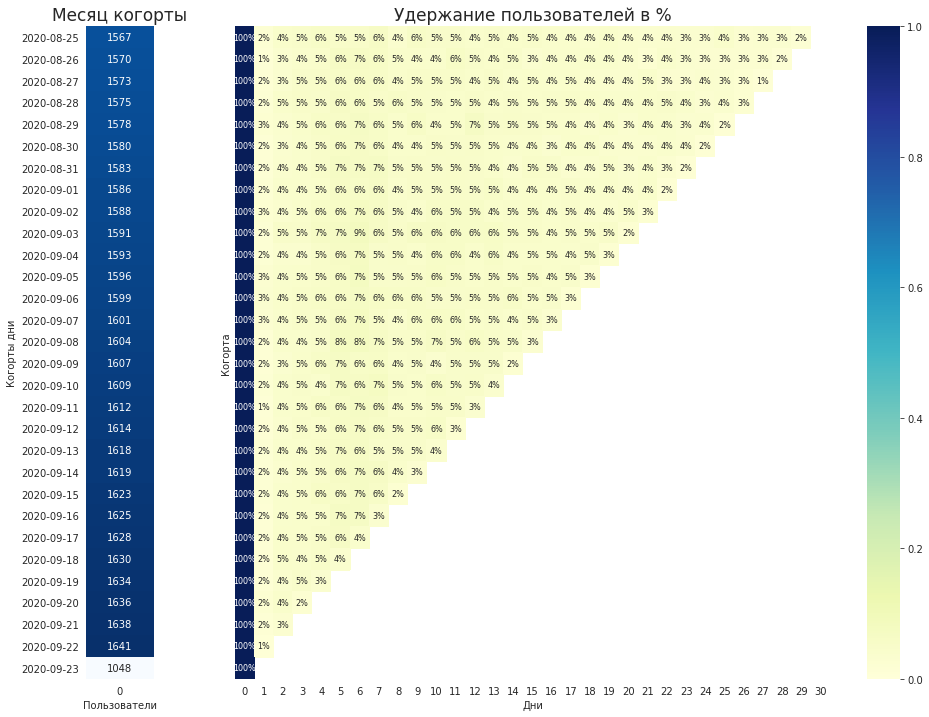

In [26]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(
        1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]}
    )

    # тепловая карта размеров когорт
    cohort_size_df = pd.DataFrame(pervi)
    sns.heatmap(
        cohort_size_df,
        annot=True,
        fmt='g',
        cbar=False,
        cmap='Blues',
        ax=ax[0]
    )
    ax[0].set_title('Месяц когорты', fontsize=17)
    ax[0].set(xlabel='Пользователи', ylabel='Когорты дни')

    # тепловая карта retention
    sns.heatmap(
        retention_30,
        vmin=0, 
        vmax=1,
        annot=True,
        fmt='.0%',
        cmap='YlGnBu',
        ax=ax[1],
        annot_kws={"size": 8}  # уменьшаем шрифт
    )
    ax[1].set_title('Удержание пользователей в %', fontsize=17)
    ax[1].set(xlabel='Дни', ylabel='Когорта')

    plt.show()

In [27]:
# Вывод: плохое уреджание пользователей.

In [28]:
# Задание № 2
# Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений.
# Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной.
# При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.
# Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

In [29]:
Data = pd.read_csv('Проект_1_Задание_2.csv', sep=';')

In [30]:
Data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [31]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB


In [32]:
# все участники уникальны (т.к. количество строк совпадает с количеством уникальных пользователей)
Data.user_id.nunique()

404770

In [33]:
# видим, что по условию выходит что группа:
# a - контрольная группа (в ней 1928 платящих игроков) ARPU в контрольной группе ниже на 5% чем в тестовой
# b - тестовая группа (в ней 1805 платящих игроков). ARPU в тестовой группе выше на 5%
# ARPU (Average Revenue Per User) — это метрика, которая показывает, сколько в среднем денег приносит один клиент 
# компании за определённый период времени
Data.testgroup.value_counts()

b    202667
a    202103
Name: testgroup, dtype: int64

In [34]:
# проводим описательную статистику контрольной группы
Data.query("testgroup == 'a'").revenue.describe()

count    202103.000000
mean         25.413720
std         920.768137
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       37433.000000
Name: revenue, dtype: float64

In [35]:
# описательная статистика для тестовый группы
Data.query("testgroup == 'b'").revenue.describe()

count    202667.000000
mean         26.751287
std         287.324162
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4000.000000
Name: revenue, dtype: float64

In [36]:
# на первый взгляд видим, что максимальная выручка контрольной группе 37433 а в тестовой 4000. Что говорит нам о выбросах
# т.е. один пользователь(или группа небольшая пользователй) вложил(ли) много денег и это частный (редкий) случай нежели среднее. Стандартное отклонение тоже
# в связи с этим std разное.

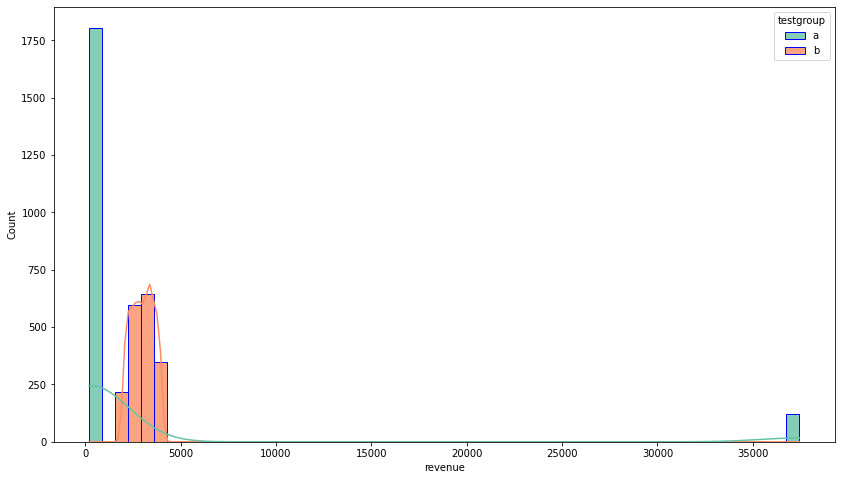

In [37]:
# посторим график для наглядоности (по платящим пользователям)

# Фильтруем только платящих пользователей
paying_players = Data[Data['revenue'] > 0]

# Построю гистограмму
plt.figure(figsize=(14, 8))
ax = sns.histplot(
    data=paying_players,
    x='revenue',
    hue='testgroup',
    kde=True,
    bins=55,
    palette='Set2',
    edgecolor='blue',
    alpha=0.8
)

In [38]:
# Вывод: тестовая группа распределяется относительно нормально. Контрольая по платящим пользователям распределяется
# не равномерно (видим что большая часть платит мало, но есть выбросы со значением выше 35000)

In [39]:
# Следующим шагом требуется проверить являются ли различия двух групп статистически значимыми по ARPU, ARPPU и  СR
# ARPU - средний доход на пользователя. Показывает, сколько в среднем приносит один пользователь за определённый период
# ARPPU - средний доход на платящего пользователя. Это средний доход только от тех пользователей, которые совершили оплату.
# СR - конверсия в платящего пользователя (рассчитывается как число платящих пользователей/число пользователей * 100)

In [40]:
 # Видим что в группе a(контрольная) ARPU  ниже (25.41), чем в тестовой группе b (26.75)
Data.groupby('testgroup', as_index=False).agg({'revenue': 'mean'})

,testgroup,revenue
0,a,25.413720
1,b,26.751287


In [41]:
# В контрольной группе a ARPPU так же ниже (2664), чем в тестовой b (3004)
Data.query('revenue > 0').groupby('testgroup', as_index=False).agg({'revenue': 'mean'})

,testgroup,revenue
0,a,2663.998444
1,b,3003.658172


In [42]:
# CR при этом в контрольной группе a выше (0.95%), чем в тестовой группе b (0.89%)
round(paying_players.testgroup.value_counts() / Data.testgroup.value_counts() * 100, 2)

a    0.95
b    0.89
Name: testgroup, dtype: float64

In [43]:
# Рузультат говорит нам, о том, что конверсия (CR) снизилась в тестовой группе b (на 0.06 %). т.е.  акнции предложенные тестовой группе
#  менее в чем-то привлекательны для  пользователей. Но ARPUU в тестовой группе выше, это значит что  акции
# для платящих пользователей в чем-то выгодны и привлекательны. 
# Распределение по платящим пользователям в контрольной группе неоднородное, большая часть пользователей совершает небольшие
# покупки, а есть выбросы (група людей), которые совершают большие покупки (свыше 35к). В тестовой группе,
# более нормальное распределение, плотно упаковано, от 2 до 4к. В целом кажется лучшу идет дело в контрольной группе. т.к.
# конверсия выше.


In [44]:
# Проверю статистическую значимость для каждой метрики.

In [45]:
# CR. Требуется сравнение категориальных(заплатил/не заплатил) переменных. Используется  хи-квадрат.


In [46]:
# H0 -  CR в контрольной и тестовой группах не различаются
# H1 - присутствует различие CR в контрольной и тестовой группах

In [47]:
# подготавливаем данные (0 - нет платы, 1 - есть плата)
Data['paid'] = np.where(Data.revenue > 0, 1, 0)

In [48]:
Data.head()

,user_id,revenue,testgroup,paid
0,1,0,b,0
1,2,0,a,0
2,3,0,a,0
3,4,0,b,0
4,5,0,b,0


In [49]:
# сам тест
stats.chi2_contingency(pd.crosstab(Data.testgroup, Data.paid))

(4.374729521260405,
 0.03647561892312613,
 1,
 array([[200239.10075104,   1863.89924896],
        [200797.89924896,   1869.10075104]]))

In [50]:
# p-value < 0.05 (0.036...), различия в конверсии между группами статистически значимы. Н0 отклоняет Н1 принимается.

In [51]:
# ARPPU
# H0 -  ARPPU в контрольной и тестовой группах не различаются
# H1 - присутствует различие ARPPU в контрольной и тестовой группах
# Для проверки статзначимости ARPU и ARPPU можно использовать T-критерий, т.к. размеры групп примерно одинаковы, 
# количество наблюдений велико, но посмотрим на гомогенность дисперсий (с помощью теста Левена)

In [52]:
con = Data.query('testgroup == "a"')
test = Data.query('testgroup == "b"')

In [53]:
# тест Левина
stat, p = levene(con.query('revenue > 0').revenue, test.query('revenue > 0').revenue)
p

3.779689868667878e-19

In [54]:
# Дисперсия неоднородна, присутствует статистически значимые различия. Получили очень маленькое число, близкое к 0.
# Поэтому для проверки ARPPU будем использовать t-критерий Уэлча.

In [55]:
# t-тест

In [56]:
stat, p = ttest_ind(con.query('revenue > 0').revenue, test.query('revenue > 0').revenue, equal_var=False)
p

0.10020780398916015

In [57]:
#  Значение p-value > 0.05, нулевая гипотеза не отклоняется. Отсуствует статистическая значимость.
# Считаем, что статистически значимых различий в ARPPU нет.

In [58]:
# ARPU
# H0 -  ARPU в контрольной и тестовой группах не различаются
# H1 - присутствует различие ARPU в контрольной и тестовой группах

In [59]:
# Проверим однородность дисперсии ARPU
scipy.stats.levene(con.revenue, test.revenue)

LeveneResult(statistic=0.3896289474701388, pvalue=0.5324948591043842)

In [60]:
#  Диспресия однородная, статистически значимых различий нет.
# Получили 0.53, что больше, чем 0.05, поэтому считаем, что дисперсии равны и далее для оценки 
# ARPU можем применить обычный t-критерий.

In [61]:
# t-тест
scipy.stats.ttest_ind(con.revenue, test.revenue)

Ttest_indResult(statistic=-0.6242026493616787, pvalue=0.532494858971837)

In [62]:
# Значение p-value > 0.05, нулевая гипотеза не отклоняется. Отсуствует статистическая значимость.
# Считаем, что статистически значимых различий в ARPU нет.

In [63]:
# Вывод
# 1. На первый взгляд казалось что  ARPU и ARPPU выше в тестовой группе, что оказалось не так. тесты показали что
# нет стат. значимых различий.
# 2. Конверсия (CR) в контролькой группе выше и стат. значимые различия есть.
# 3. Аукционные предложение необходимо выбирать те, которые давались контрольной группе.

In [64]:
# Задание 3
# В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени.
# В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. 
# Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты 
# последнего прошедшего события?

# Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок 
# будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

In [65]:
# Оценить рузультаты последнего прошедшего события можно следующими метриками:

# Conversion Rate (CR) - Процент пользователей, совершивших покупку (Конверсия)
# ARPU (Average Revenue Per User) - Средний доход от одного пользователя
# ARPPU (Average Revenue Per Paying User) - Средний доход с платящего пользователя
# Event Revenue - общий доход, полученный от проведения мероприятия
# DAU / WAU  — ежедневная и еженедельная активность во время события
# Retention Rate - удержание (насколько удерживает и возвращаются ли)
# Participation Rate - Какая доля игроков решила поучаствовать в событии
# Average Levels Completed — среднее количество уровней, пройденных игроками
# Time to Completion — среднее время до полного прохождения события

In [66]:
# Метрики после усложнения механики:

# Drop-off Rate per Level — на каких уровнях игроки чаще всего бросают игру
# Failure Rate per Level — доля неудачных попыток на каждом уровне
# Churn Rate - Какая доля пользователей ушла после усложнения механики